Differential Imaging Attack (DIA) on RMIST-Net

This script:
  1) Rebuilds RMIST-Net and loads trained weights.
  2) Loads real SAR data, precomputed attack pool D, and RM kernels.
  3) Sets up a differentiable RMA imaging layer in PyTorch.
  4) Reparameterizes the complex gain vector A via latent variables Z.
  5) Optimizes A so that RMIST-Net’s output magnitude matches a desired
     camouflaged template (desired_attacked).
  6) Reports image-space and RMIST-level metrics and visualizes results.

In [ ]:
# Imports 
import os
import math
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

- Core RMIST-net

In [ ]:
#--------------------- forward kernel and adjoint kernel (imaging kernal)

# ----------------------------------------------------------------------
# RMIST‑Net and helper functions (kernel generation, forward/adjoint, network)
# ----------------------------------------------------------------------
def make_rm_kernels(H, W, R, fc=78.3e9, c=3e8, device="cpu"):
    """
    Build RM forward and adjoint kernels φ_r and φ_r^† on (kx, kz) grid.

    S = RM(α) = IFFT2( FFT2(α) * φ_r )
    α = RM^†(S) = IFFT2( FFT2(S) * φ_r^† )

    H, W : image size (rows=z, cols=x)
    R : range slice (scalar)
    """
    # Image-domain coordinates (relative units)
    x = torch.linspace(-W / 2, W / 2, W, device=device)
    z = torch.linspace(-H / 2, H / 2, H, device=device)
    dx = x[1] - x[0]
    dz = z[1] - z[0]

    # Spatial frequency sampling
    dkx = 2 * math.pi / (W * dx)
    dkz = 2 * math.pi / (H * dz)
    kx = torch.linspace(-W / 2, W / 2, W, device=device) * dkx
    kz = torch.linspace(-H / 2, H / 2, H, device=device) * dkz

    # Meshgrid (Kx, Kz)
    Kx, Kz = torch.meshgrid(kx, kz, indexing="xy")
    K0 = 2 * math.pi * fc / c
    K_sq = Kx**2 + Kz**2
    K_check = 4 * (K0**2) - K_sq
    Ky = torch.sqrt(torch.clamp(K_check, min=0.0))

    # Forward kernel φ_r
    Ky_safe = torch.where(Ky == 0, torch.ones_like(Ky), Ky)
    phi = (1.0 / Ky_safe) * torch.exp(-1j * Ky * R)
    phi = torch.where(Ky == 0, torch.zeros_like(phi), phi)

    # Adjoint kernel φ_r^†
    phi_dag = Ky * torch.exp(1j * Ky * R)

    return phi, phi_dag  # each (W, H) complex


def rm_forward(alpha_ri, phi):
    """
    RM forward: S = RM(α)
    alpha_ri : (B, 2, H, W) [Re, Im]
    phi      : (W, H) complex kernel φ_r
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = alpha_ri.shape
    alpha = torch.complex(alpha_ri[:, 0], alpha_ri[:, 1])  # (B,H,W)
    F_alpha = torch.fft.fft2(alpha)

    # Ensure phi is (H, W)
    if phi.shape[0] == W and phi.shape[1] == H:
        phi_hw = phi.permute(1, 0)
    else:
        phi_hw = phi

    S = F_alpha * phi_hw
    s = torch.fft.ifft2(S)
    return torch.stack([s.real, s.imag], dim=1)


def rm_adjoint(s_ri, phi_dag):
    """
    RM adjoint: α = RM^†(S)
    s_ri     : (B, 2, H, W) [Re, Im]
    phi_dag  : (W, H) complex kernel φ_r^†
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = s_ri.shape
    s = torch.complex(s_ri[:, 0], s_ri[:, 1])
    F_s = torch.fft.fft2(s)

    if phi_dag.shape[0] == W and phi_dag.shape[1] == H:
        phi_dag_hw = phi_dag.permute(1, 0)
    else:
        phi_dag_hw = phi_dag

    A = F_s * phi_dag_hw
    a = torch.fft.ifft2(A)
    return torch.stack([a.real, a.imag], dim=1)


# -----------------------------  RMIST-Net
class RMISTPhase(nn.Module):
    """
    One unrolled ISTA phase:
      v_t       = S - RM(α_t)
      r_t       = α_t + τ_t * RM^†(v_t)
      α_{t+1}   = F_st(r_t, θ_t)
    with complex soft-thresholding F_st.
    """

    def __init__(self, phi, phi_dag):
        super().__init__()
        # Fixed physics kernels
        self.register_buffer("phi", phi)
        self.register_buffer("phi_dag", phi_dag)
        # Trainable scalars τ_t, θ_t
        self.tau = nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))
        self.theta = nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))

    def soft_thresh(self, r):
        """
        Complex soft thresholding:
          α_next = r * max(|r| - θ, 0) / |r|
        r : (B, 2, H, W) [Re, Im]
        """
        real = r[:, 0]
        imag = r[:, 1]
        mag = torch.sqrt(real**2 + imag**2 + 1e-12)
        shr = torch.relu(mag - self.theta)  # max(|r|-θ, 0)
        scale = shr / (mag + 1e-12)
        real2 = real * scale
        imag2 = imag * scale
        return torch.stack([real2, imag2], dim=1)

    def forward(self, S_ri, alpha_ri):
        # Stage 1: residual v_t = S - RM(α_t)
        RM_alpha = rm_forward(alpha_ri, self.phi)
        v = S_ri - RM_alpha

        # Stage 2: gradient step r_t = α_t + τ_t * RM^†(v_t)
        grad = rm_adjoint(v, self.phi_dag)
        r = alpha_ri + self.tau * grad

        # Stage 3: shrinkage α_{t+1} = F_st(r_t, θ_t)
        alpha_next = self.soft_thresh(r)
        return alpha_next


class RMISTNet(nn.Module):
    """
    RMIST-Net: T-phase unrolled RM + ISTA sparse reconstruction network.
    """

    def __init__(self, H, W, R, fc=78.3e9, c=3e8, T=6, device="cpu"):
        super().__init__()
        phi, phi_dag = make_rm_kernels(H, W, R, fc, c, device=device)
        self.phases = nn.ModuleList([RMISTPhase(phi, phi_dag) for _ in range(T)])

    def forward(self, S_ri):
        # Initialization: α_0 = RM^†(S)
        alpha = rm_adjoint(S_ri, self.phases[0].phi_dag)

        # Unroll T ISTA phases
        for phase in self.phases:
            alpha = phase(S_ri, alpha)
        return alpha

- RMA (traditional)

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

# ----------------------------------------------------------------------
# RMA focusing from raw time‑domain data (torch implementation)
# ----------------------------------------------------------------------

def rma_torch(sar_data, params_torch):
    """
    RMA starting from RAW time-domain data.
    sar_data: (Nsamp, M*N) complex (torch.complex64)
    Returns: (img_norm, img_centered) size (nFFTspace, nFFTspace)
    """
    device = sar_data.device

    # -------- RAW -> sarData (M,N) via FFT + range-bin ----------
    Nsamp        = params_torch["Nsamp"]
    M            = params_torch["M"]
    N            = params_torch["N"]
    nFFTtime     = params_torch["nFFTtime"]
    k0_range_bin = params_torch["k0_range_bin"]

    Y_cube = sar_data.reshape(Nsamp, M, N)                  # (Nsamp, M, N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))          # (N, M, Nsamp)
    rawFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)    # (N, M, nFFTtime)
    sar_slice = rawFFT[:, :, k0_range_bin]             # (N, M)
    sarData   = sar_slice.permute(1, 0)                # (M, N)

    for rr in range(1, M, 2):
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    # ------------------- RMA focusing -------------------
    nFFTspace = params_torch["nFFTspace"]
    dx = params_torch["dx"]
    dy = params_torch["dy"]
    F0 = params_torch["F0"]
    z0 = params_torch["z0"]
    c = 3e8
    k = 2 * np.pi * F0 / c

    Mloc, Nloc = sarData.shape
    pad_x = nFFTspace - Nloc
    pad_y = nFFTspace - Mloc
    pad_x_pre = pad_x // 2
    pad_x_post = pad_x - pad_x_pre
    pad_y_pre = pad_y // 2
    pad_y_post = pad_y - pad_y_pre

    sarData_padded = F.pad(
        sarData.unsqueeze(0).unsqueeze(0),
        (pad_x_pre, pad_x_post, pad_y_pre, pad_y_post),
    )[0, 0, :, :]

    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)
    kX = np.linspace(-wSx / 2, wSx / 2, nFFTspace)
    kY = np.linspace(-wSy / 2, wSy / 2, nFFTspace)
    KX_np, KY_np = np.meshgrid(kX, kY)
    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K2 = (2 * k) ** 2 - (KX_t**2 + KY_t**2)
    K2 = torch.clamp(K2, min=0.0)
    Kz = torch.sqrt(K2)

    phase0 = torch.exp(-1j * z0 * Kz)
    ev_mask = (KX_t**2 + KY_t**2) > (2 * k) ** 2
    phase0[ev_mask] = 0.0 + 0.0j

    phase = Kz * phase0
    phase = torch.fft.fftshift(torch.fft.fftshift(phase, dim=0), dim=1)

    sarFFT = torch.fft.fft2(sarData_padded)
    img = torch.fft.ifft2(sarFFT * phase)
    img = torch.fft.fftshift(img, dim=(0, 1))

    mag = torch.abs(img)
    idx = torch.argmax(mag)
    i_max = int(idx // mag.shape[1])
    j_max = int(idx % mag.shape[1])
    center = (nFFTspace - 1) / 2.0
    img = torch.roll(torch.roll(img, int(round(center - i_max)), 0), int(round(center - j_max)), 1)

    img_mag = torch.abs(img)
    #img_norm = img_mag / (torch.sqrt(torch.mean(img_mag**2) + 1e-12))
    return img_mag, img

def S_hat_from_alpha(alpha_complex_torch, Phi_r_dag_torch):
    """
    S_hat = RM(α) in frequency domain:
      F_A   = fft2(α)
      S_tmp = F_A * Phi_r_dag
      S_hat = ifft2(S_tmp) / global_max
    """
    F_A = torch.fft.fft2(alpha_complex_torch)
    S_tmp = F_A * Phi_r_dag_torch
    S_hat = torch.fft.ifft2(S_tmp)
    #S_hat_norm = S_hat / (global_max + 1e-12)
    #return S_hat_norm
    return S_hat

- Victim forward model (RMA only or RMA + RMIST-Net) and generate target image

In [ ]:
def victim_forward(
    raw_vec: torch.Tensor,                 # (Nsamp, M*N) complex
    params_torch: dict,
    mode: str = "rma+rmist",                # "rma" or "rma+rmist"
    model: torch.nn.Module | None = None,
    Phi_r_dag: torch.Tensor | None = None,
    do_rms_norm: bool = False,
):
    """
    raw_vec: (Nsamp, M*N) complex torch tensor

    returns:
      mode="rma"       -> (rma_img_mag, rma_img_cplx)
      mode="rma+rmist" -> (rma_img_mag, rma_img_cplx, alpha_mag)

    Uses rma_torch() and S_hat_from_alpha().
    """
    rma_img_mag, rma_img_cplx = rma_torch(raw_vec, params_torch)

    if mode == "rma":
        return rma_img_mag, rma_img_cplx

    if model is None or Phi_r_dag is None:
        raise ValueError("mode='rma+rmist' requires model and Phi_r_dag.")

    H, W = Phi_r_dag.shape

    if rma_img_cplx.shape != (H, W):
        ph = (rma_img_cplx.shape[0] - H) // 2
        pw = (rma_img_cplx.shape[1] - W) // 2
        img_crop = rma_img_cplx[ph:ph+H, pw:pw+W]
    else:
        img_crop = rma_img_cplx

    S_hat = S_hat_from_alpha(img_crop, Phi_r_dag)

    S_hat_t = torch.stack([S_hat.real, S_hat.imag], dim=0).unsqueeze(0)
    S_hat_t = S_hat_t.to(torch.float32).to(raw_vec.device)

    alpha_pred = model(S_hat_t)  # (1,2,H,W)

    alpha_mag = torch.sqrt(alpha_pred[:, 0]**2 + alpha_pred[:, 1]**2 + 1e-12).unsqueeze(1)  # (1,1,H,W)
    if do_rms_norm:
        alpha_mag = alpha_mag / torch.sqrt(torch.mean(alpha_mag**2) + 1e-12)

    return rma_img_mag, rma_img_cplx, alpha_mag

In [ ]:
dataDir     = os.path.join(os.getcwd(), "data")
raw_dataDir = os.path.join(os.getcwd(), "raw_sar_data")
dir_path = os.getcwd()

# ------------------------------------------------------------
# USER OPTIONS (match MATLAB knobs)
# ------------------------------------------------------------
victim_mode      = "rma+rmist"     # fixed for RMIST pipeline
target_mode      = "object"         # "noise" or "object"

target_raw_select = 1              # target raw cube index (1..10) if object mode

rawData_select   = 10               # victim raw cube index (1..10)

############################################################
# -------------------------
# Attack hyperparameters
# -------------------------
num_iters  = 1000
lambda_L2  = 1e-5

lr         = 1e-2

# -------------------------
# Constraint toggles
# -------------------------
use_amax_projection  = False
Amax                 = 2.0

use_pa_pr_projection = True
PaPr_max_dB          = -10.0
PaPr_max             = 10 ** (PaPr_max_dB / 10.0)
############################################################

In [ ]:
# list (match MATLAB names)
rawData = [
    "knife",                 # 1W
    "plier",                 # 2
    "scissor",               # 3
    "screw_driver",          # 4
    "sharp_paint_speader",   # 5
    "dragger",               # 6
    "wrench",                # 7
    "gun",                   # 8
    "rifle",                 # 9
    "butcher_knife",               # 10
]

victim_name = rawData[rawData_select - 1]
tgt_name    = rawData[target_raw_select - 1]

# ------------------------------------------------------------
# VICTIM PARAMS (dx,dy,z0,FS) — EXACTLY like MATLAB switch
# ------------------------------------------------------------
if victim_name == "knife":
    dx, dy, z0_mm, FS = 1, 1, 185, 5_000_000.0
elif victim_name == "plier":
    dx, dy, z0_mm, FS = 1, 2, 210, 5_000_000.0
elif victim_name == "scissor":
    dx, dy, z0_mm, FS = 1, 2, 215, 5_000_000.0
elif victim_name == "screw_driver":
    dx, dy, z0_mm, FS = 1, 2, 230, 5_000_000.0
elif victim_name == "sharp_paint_speader":
    dx, dy, z0_mm, FS = 1, 2, 180, 5_000_000.0
elif victim_name == "dragger":
    dx, dy, z0_mm, FS = 1, 2, 195, 5_000_000.0
elif victim_name == "wrench":
    dx, dy, z0_mm, FS = 1, 1, 170, 9_121_000.0
elif victim_name == "gun":
    dx, dy, z0_mm, FS = 1, 1, 185, 9_121_000.0
elif victim_name == "rifle":
    dx, dy, z0_mm, FS = 1, 1, 185, 9_121_000.0
elif victim_name == "butcher_knife":
    dx, dy, z0_mm, FS = 1, 2, 210, 5_000_000.0
else:
    raise ValueError(f"Unknown victim selection: {victim_name}")

# ------------------------------------------------------------
# TARGET PARAMS (only if object mode) — EXACTLY like MATLAB switch
# ------------------------------------------------------------
if target_mode.lower() == "object":
    if tgt_name == "knife":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 5_000_000.0
    elif tgt_name == "plier":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 220, 5_000_000.0
    elif tgt_name == "scissor":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 215, 5_000_000.0
    elif tgt_name == "screw_driver":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 230, 5_000_000.0
    elif tgt_name == "sharp_paint_speader":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 180, 5_000_000.0
    elif tgt_name == "dragger":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 195, 5_000_000.0
    elif tgt_name == "wrench":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 170, 9_121_000.0
    elif tgt_name == "gun":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 9_121_000.0
    elif tgt_name == "rifle":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 9_121_000.0
    elif tgt_name == "butcher_knife":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 210, 5_000_000.0
    else:
        raise ValueError(f"Unknown target selection: {tgt_name}")
    
# ------------------------------------------------------------
# CONSTANTS (match MATLAB)
# ------------------------------------------------------------
c0 = 3e8
F0 = 77e9
K0 = 70.295e12
tI = 4.5225e-10
EPS = 1e-12

# nFFTspace fixed for RMIST input; nFFTtime tied to Nsamp after load
nFFTspace = 512

# ============================================================
# LOAD D, Phi_r_dag, MODEL WEIGHTS
# ============================================================
#D_np = loadmat(os.path.join(dataDir, "D.mat"))["D"]
#D_t  = torch.tensor(D_np.astype(np.complex64), dtype=torch.complex64, device=device)  # (Nsamp,Np) ideally

Phi_np = loadmat(os.path.join(dataDir, "Phi_r_dag_gun.mat"))["Phi_r_dag"]
Phi_r_dag = torch.tensor(Phi_np.astype(np.complex64), dtype=torch.complex64, device=device)  # (H,W)

H, W = Phi_r_dag.shape
R_mat = 0.185
T_phases = 9

model = RMISTNet(H, W, R=R_mat, device=device, T=T_phases).to(device)
state_dict = torch.load(os.path.join(dir_path, "trained_model", "RMISTNet_weights.pth"),
                        map_location=device)
model.load_state_dict(state_dict)
model.eval()


# ============================================================
# 8) LOAD VICTIM RAW -> X_v (Nsamp,Np) + AUTO BIN (RMA-style) + overrides
# ============================================================
victim_path = os.path.join(raw_dataDir, f"{victim_name}.mat")
sarRawData = loadmat(victim_path)["adcDataCube"]  # (Nsamp,M,N)
Nsamp, M, N = sarRawData.shape
Np = M * N

X_v_np = sarRawData.reshape(Nsamp, Np).astype(np.complex64)
X_v_t  = torch.tensor(X_v_np, dtype=torch.complex64, device=device)

# RMA-style bin pick
Echo = np.transpose(sarRawData, (2, 1, 0))               # (N,M,Nsamp)
nFFTtime = Echo.shape[2]
rawFFT = np.fft.fft(Echo, n=nFFTtime, axis=2)
E = np.sum(np.sum(np.abs(rawFFT)**2, axis=0), axis=0)
k0_bin_1b = int(np.argmax(E) + 1)

# overrides
if victim_name in {"screw_driver", "gun", "rifle"}:
    k0_bin_1b = 8
if victim_name == "wrench":
    k0_bin_1b = 7

z0_m = (c0 / 2.0) * (((k0_bin_1b - 1) / (K0 * (1.0 / FS) * nFFTtime)) - tI)

params_torch = {
    "Nsamp": Nsamp, "M": M, "N": N,
    "nFFTtime": nFFTtime,
    "k0_range_bin": (k0_bin_1b - 1),     # 0-based
    "nFFTspace": nFFTspace,
    "dx": float(dx), "dy": float(dy),
    "F0": float(F0), "z0": float(z0_m),
}

print(f"[Victim] {victim_name} | Nsamp={Nsamp}, M={M}, N={N}, Np={Np}")
print(f"[Victim] dx={dx}, dy={dy}, FS={FS:.0f}, k0_bin={k0_bin_1b}, z0(m)={z0_m:.4f}")


# ============================================================
# BUILD ATTACK WAVEFORM BANK D_t  (same as your working X_aa path)
# ============================================================
def load_mat_variable_auto(path, key):
    try:
        return loadmat(path)[key]
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            arr = np.array(f[key])
            arr = arr.T
            if np.iscomplexobj(arr):
                return arr
            if arr.dtype.names is not None and "real" in arr.dtype.names and "imag" in arr.dtype.names:
                return arr["real"] + 1j * arr["imag"]
            return arr

# ---- Load X_aa.mat
Xaa1_np = load_mat_variable_auto(os.path.join(dataDir, "X_aa.mat"), "X_aa")
X_aa_1 = torch.tensor(Xaa1_np.astype(np.complex64), dtype=torch.complex64, device=device)

# ---- Load X_aa_2.mat if present
X_aa_2 = None
xaa2_path = os.path.join(dataDir, "X_aa_2.mat")
if os.path.exists(xaa2_path):
    Xaa2_np = load_mat_variable_auto(xaa2_path, "X_aa")
    X_aa_2 = torch.tensor(Xaa2_np.astype(np.complex64), dtype=torch.complex64, device=device)

# ---- Same MATLAB branching
if Nsamp == 512 and (M * N) > 40000 and (X_aa_2 is not None):
    X_aa_temp = torch.cat([X_aa_1, X_aa_2], dim=0)
    X_aa = torch.cat([X_aa_temp, X_aa_temp], dim=1)
elif Nsamp == 512 and (M * N) == 40000 and (X_aa_2 is not None):
    X_aa = torch.cat([X_aa_1, X_aa_2], dim=0)
else:
    X_aa = X_aa_1

    
# ---- MATLAB:
# targetK = M*N;
# rng(0);
# sample_idx = randi(size(X_aa,2), [1,targetK]);
targetK = M * N
rng_np = np.random.default_rng(0)
sample_idx = rng_np.integers(low=0, high=X_aa.shape[1], size=targetK, endpoint=False)
X_a_pool = X_aa[:, sample_idx]

# ---- MATLAB:
# sel_idx = randi(size(X_a_pool,2), [1,Np]);
# X_a     = X_a_pool(:, sel_idx);
sel_idx = rng_np.integers(low=0, high=X_a_pool.shape[1], size=Np, endpoint=False)
X_a = X_a_pool[:, sel_idx]

# ---- MATLAB:
# Xspec   = fft(X_a, nFFTtime, 1);
# [~, b0] = max(abs(Xspec), [], 1);
Xspec = torch.fft.fft(X_a, n=nFFTtime, dim=0)
b0 = torch.argmax(torch.abs(Xspec), dim=0)   # 0-based

# ---- MATLAB:
# f0_col  = (b0 - 1) * FS / nFFTtime;
# f_tgt   = (params.k0_range_bin) * FS / nFFTtime;
f0_col = b0.to(torch.float32) * FS / nFFTtime
f_tgt = params_torch["k0_range_bin"] * FS / nFFTtime

Delta = f0_col - f_tgt

# ---- MATLAB:
# t = (0:Nsamp-1).' / FS;
# P = exp(-1j * 2*pi * (t * Delta));
t = torch.arange(Nsamp, device=device, dtype=torch.float32).unsqueeze(1) / FS
P = torch.exp(-1j * 2 * math.pi * t * Delta.unsqueeze(0))

# ---- MATLAB:
# D = P .* X_a;
D_t = P * X_a

# ---- MATLAB:
# colrms = @(X) sqrt(mean(abs(X).^2, 1));
def colrms_torch(X):
    return torch.sqrt(torch.mean(torch.abs(X) ** 2, dim=0))

# ---- MATLAB:
# scale  = (colrms(X_v) + eps) ./ (colrms(D) + eps);
# D      = D .* scale;
scale = (colrms_torch(X_v_t) + EPS) / (colrms_torch(D_t) + EPS)
D_t = D_t * scale.unsqueeze(0)

print(f"[X_aa] X_aa shape    : {tuple(X_aa.shape)}")
print(f"[X_aa] X_a_pool shape: {tuple(X_a_pool.shape)}")
print(f"[X_aa] X_a shape     : {tuple(X_a.shape)}")
print(f"[X_aa] D_t shape     : {tuple(D_t.shape)}")

## Clean and target image

In [ ]:
# ============================================================
# 9) CLEAN + TARGET via victim_forward()
# ============================================================
mode = "rma+rmist"
# ============================================================
# 9) CLEAN + TARGET via victim_forward()
# ============================================================
with torch.no_grad():
    if mode == "rma":
        _, _ = victim_forward(X_v_t, params_torch, mode="rma")
        # For "rma" mode, we define clean_img from rma magnitude for compatibility
        clean_mag, _ = victim_forward(X_v_t, params_torch, mode="rma")
        clean_img = clean_mag.unsqueeze(0).unsqueeze(0)  # (1,1,H,W) placeholder in that case
    else:
        _, _, clean_img = victim_forward(
            X_v_t, params_torch,
            mode="rma+rmist",
            model=model,
            Phi_r_dag=Phi_r_dag,
            do_rms_norm=False
        )  # (1,1,H,W)

global_scale = clean_img.abs().amax() + EPS
clean_img = clean_img / global_scale
#clean_img = clean_img / clean_img.abs().amax() + EPS

# ---- TARGET
if target_mode.lower() == "noise":
    rng = np.random.default_rng(42)
    X_shuf_np = X_v_np.copy()


    #for t in range(Nsamp):
    #    X_shuf_np[t, :] = X_shuf_np[t, rng.permutation(Np)]
    perm = rng.permutation(X_shuf_np.size)   # one global permutation
    X_shuf_np = X_shuf_np.reshape(-1)[perm].reshape(X_shuf_np.shape)

    X_shuf_t = torch.tensor(X_shuf_np, dtype=torch.complex64, device=device)
    
    with torch.no_grad():
        if mode == "rma":
            target_mag, _ = victim_forward(X_shuf_t, params_torch, mode="rma")
            target_img = target_mag.unsqueeze(0).unsqueeze(0)
        else:
            _, _, target_img = victim_forward(
                X_shuf_t, params_torch,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False
            )

    #target_img = target_img /global_scale 
    target_img = target_img /  (target_img.abs().amax() + EPS)

elif target_mode.lower() == "object":
    tgt_path = os.path.join(raw_dataDir, f"{tgt_name}.mat")
    sarRawData_tgt = loadmat(tgt_path)["adcDataCube"]
    Nsamp_t, M_t, N_t = sarRawData_tgt.shape
    Np_t = M_t * N_t

    X_tgt_np = sarRawData_tgt.reshape(Nsamp_t, Np_t).astype(np.complex64)
    X_tgt_t  = torch.tensor(X_tgt_np, dtype=torch.complex64, device=device)

    # target bin pick + overrides (RMA style)
    Echo_t = np.transpose(sarRawData_tgt, (2, 1, 0))
    nFFTtime_t = Echo_t.shape[2]
    rawFFT_t = np.fft.fft(Echo_t, n=nFFTtime_t, axis=2)
    E_t = np.sum(np.sum(np.abs(rawFFT_t)**2, axis=0), axis=0)
    kbin_t_1b = int(np.argmax(E_t) + 1)

    if tgt_name in {"screw_driver", "gun", "rifle"}:
        kbin_t_1b = 8
    if tgt_name == "wrench":
        kbin_t_1b = 7

    z0_t_m = (c0 / 2.0) * (((kbin_t_1b - 1) / (K0 * (1.0 / FS_tgt) * nFFTtime_t)) - tI)

    params_tgt = {
        "Nsamp": Nsamp_t, "M": M_t, "N": N_t,
        "nFFTtime": nFFTtime_t,
        "k0_range_bin": (kbin_t_1b - 1),
        "nFFTspace": nFFTspace,
        "dx": float(dx_t), "dy": float(dy_t),
        "F0": float(F0), "z0": float(z0_t_m),
    }

    print(f"[Target] {tgt_name} | Nsamp={Nsamp_t}, M={M_t}, N={N_t}, Np={Np_t}")
    print(f"[Target] dx={dx_t}, dy={dy_t}, FS={FS_tgt:.0f}, k0_bin={kbin_t_1b}, z0(m)={z0_t_m:.4f}")

    with torch.no_grad():
        if mode == "rma":
            target_mag, _ = victim_forward(X_tgt_t, params_tgt, mode="rma")
            target_img = target_mag.unsqueeze(0).unsqueeze(0)
        else:
            _, _, target_img = victim_forward(
                X_tgt_t, params_tgt,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False
            )
    target_img = target_img /  target_img.abs().amax() + EPS
    #target_img = target_img /global_scale 
else:
    raise ValueError("target_mode must be 'noise' or 'object'")

print("clean_img  |.| min/max:", clean_img.abs().min().item(), "/", clean_img.abs().max().item())
print("target_img |.| min/max:", target_img.abs().min().item(), "/", target_img.abs().max().item())
print("clean_img :", tuple(clean_img.shape), clean_img.dtype, clean_img.device)
print("target_img:", tuple(target_img.shape), target_img.dtype, target_img.device)

# ---- quick visualization
clean2d  = clean_img.detach().abs().squeeze().cpu().numpy()
target2d = target_img.detach().abs().squeeze().cpu().numpy()

clean2d  = np.fliplr(clean2d)
target2d = np.fliplr(target2d)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean2d, cmap="gray", origin="lower")
plt.title("Clean (rma+rmist)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(target2d, cmap="gray", origin="lower")
plt.title("Target")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## DIA Optimization

In [416]:
# ============================================================
# DIA OPTIMIZATION over complex gains A (Np,) with MATLAB-like
# power projection: step -> projection -> evaluate feasible iterate
# ============================================================

import math
import torch
import torch.nn.functional as F

# -------------------------
# Attack hyperparameters
# -------------------------
#num_iters  = 1000
#lambda_L2  = 1e-5
#lr         = 1e-1


EPS        = 1e-12
# -------------------------
# Constraint toggles
# -------------------------
#use_amax_projection  = False
#Amax                 = 2.0

#use_pa_pr_projection = True
#PaPr_max_dB          = -10.0
#PaPr_max             = 10 ** (PaPr_max_dB / 10.0)

# Reference signal power
Pr_ref = (torch.linalg.norm(X_v_t) ** 2 + EPS).item()

# -------------------------
# Optimization variables
# -------------------------
A_re = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))
A_im = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))
optimizer = torch.optim.Adam([A_re, A_im], lr=lr)

# -------------------------
# Early-stop knobs
# MATLAB-style diminishing returns
# -------------------------
maxIter_cap  = num_iters
check_every  = 25
W_win        = 100
rel_drop_min = 1e-2
abs_drop_min = 0.0
K_weak       = 3
weakWinCount = 0

# -------------------------
# History trackers
# -------------------------
loss_hist   = []
meanA_hist  = []
maxA_hist   = []
PaPr_hist   = []
PaPrdB_hist = []

bestLoss = float("inf")
bestIter = 0

A_re_best = A_re.detach().clone()
A_im_best = A_im.detach().clone()

print(
    f"\nOptimizing complex gain A for all locations (Np={Np}) with victim pipeline: {victim_mode} "
    f"| lr={lr:.3g} | lambda_L2={lambda_L2:.3g} | "
    f"Pa/Pr<={PaPr_max_dB:.2f} dB ({int(use_pa_pr_projection)}) | "
    f"|A|<={Amax:.3g} ({int(use_amax_projection)})\n"
)

iter = 0
while True:
    if iter >= maxIter_cap:
        print(f"Reached maxIter cap ({maxIter_cap}).")
        break

    iter += 1

    # =========================================================
    # 1) Forward / gradients through full pipeline
    # =========================================================
    optimizer.zero_grad()

    A_raw = torch.complex(A_re, A_im)                    # (Np,)
    delta = D_t * A_raw.unsqueeze(0)                     # (Nsamp, Np)
    X_adv = X_v_t + delta                                # (Nsamp, Np)

    if victim_mode == "rma":
        adv_mag, _ = victim_forward(X_adv, params_torch, mode="rma")
        adv_img = adv_mag.unsqueeze(0).unsqueeze(0)      # (1,1,H,W)
        adv_img = adv_img / global_scale
    else:
        _, _, adv_img = victim_forward(
            X_adv,
            params_torch,
            mode="rma+rmist",
            model=model,
            Phi_r_dag=Phi_r_dag,
            do_rms_norm=False
        )                                                # (1,1,H,W)
        adv_img = adv_img / global_scale

    loss_img = F.mse_loss(adv_img, target_img)
    loss_reg = lambda_L2 * torch.mean(torch.abs(A_raw) ** 2)
    loss = loss_img + loss_reg

    loss.backward()
    optimizer.step()

    # =========================================================
    # 2) Projection(s) on UPDATED A
    #    same idea as MATLAB reference
    # =========================================================
    with torch.no_grad():
        A_num = torch.complex(A_re, A_im)

        # -----------------------------------------------------
        # Projection 1: |A| <= Amax
        # -----------------------------------------------------
        if use_amax_projection:
            mags = torch.abs(A_num)
            scale_amax = torch.ones_like(mags)
            over = mags > Amax
            scale_amax[over] = Amax / (mags[over] + EPS)
            A_num = A_num * scale_amax

        # -----------------------------------------------------
        # Projection 2: enforce Pa/Pr <= PaPr_max
        # -----------------------------------------------------
        delta_now = D_t * A_num.unsqueeze(0)
        Pa_now = (torch.linalg.norm(delta_now) ** 2).item()
        PaPr_now = Pa_now / Pr_ref

        if use_pa_pr_projection and (PaPr_now > PaPr_max):
            scale_pow = math.sqrt(PaPr_max / (PaPr_now + EPS))
            A_num = A_num * scale_pow

            delta_now = D_t * A_num.unsqueeze(0)
            Pa_now = (torch.linalg.norm(delta_now) ** 2).item()
            PaPr_now = Pa_now / Pr_ref

        PaPr_now_dB = 10.0 * math.log10(PaPr_now + EPS)

        # write back projected A
        A_re.copy_(A_num.real)
        A_im.copy_(A_num.imag)

        meanA_now = torch.mean(torch.abs(A_num)).item()
        maxA_now  = torch.max(torch.abs(A_num)).item()

    # =========================================================
    # 3) Evaluate POST-projection loss (feasible iterate)
    # =========================================================
    with torch.no_grad():
        A_con = torch.complex(A_re, A_im)
        delta_con = D_t * A_con.unsqueeze(0)
        X_con = X_v_t + delta_con

        if victim_mode == "rma":
            adv_mag2, _ = victim_forward(X_con, params_torch, mode="rma")
            adv_img2 = adv_mag2.unsqueeze(0).unsqueeze(0)
            adv_img2 = adv_img2 / (adv_img2.abs().amax() + EPS)
        else:
            _, _, adv_img2 = victim_forward(
                X_con,
                params_torch,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False
            )
            adv_img2 = adv_img2 / global_scale

        loss_img2 = F.mse_loss(adv_img2, target_img)
        loss_reg2 = lambda_L2 * torch.mean(torch.abs(A_con) ** 2)
        loss_post = loss_img2 + loss_reg2
        lossVal = float(loss_post.item())

        mse_AT = loss_img2.item()
        mse_CA = F.mse_loss(adv_img2, clean_img).item()

        g_re = 0.0 if A_re.grad is None else torch.max(torch.abs(A_re.grad)).item()
        g_im = 0.0 if A_im.grad is None else torch.max(torch.abs(A_im.grad)).item()
        Gnow = max(g_re, g_im)

    # =========================================================
    # 4) Track stats
    # =========================================================
    loss_hist.append(lossVal)
    meanA_hist.append(meanA_now)
    maxA_hist.append(maxA_now)
    PaPr_hist.append(PaPr_now)
    PaPrdB_hist.append(PaPr_now_dB)

    # =========================================================
    # 5) Update best
    # =========================================================
    if lossVal < bestLoss:
        bestLoss = lossVal
        bestIter = iter
        A_re_best = A_re.detach().clone()
        A_im_best = A_im.detach().clone()

    # =========================================================
    # 6) Logging
    # =========================================================
    if (iter % 25 == 0) or (iter == 1) or (iter == maxIter_cap):
        print(
            f"Iter {iter:04d} | Loss={lossVal:.4e} (best={bestLoss:.4e} @{bestIter}) | "
            f"G={Gnow:.6e} | MSE(A,T)={mse_AT:.4e}, MSE(C,A)={mse_CA:.4e} | "
            f"E|A|={meanA_now:.4e}, max|A|={maxA_now:.4e} | "
            f"Pa/Pr={PaPr_now:.4e} ({PaPr_now_dB:.2f} dB)"
        )

    # =========================================================
    # 7) Early stop: diminishing returns over a window
    # =========================================================
    if iter > W_win and (iter % check_every == 0):
        L_old = loss_hist[iter - W_win - 1]
        L_new = loss_hist[iter - 1]

        rel_drop = (L_old - L_new) / max(abs(L_old), 1e-12)
        abs_drop = (L_old - L_new)

        if abs_drop_min > 0:
            isWeak = (rel_drop < rel_drop_min) and (abs_drop < abs_drop_min)
        else:
            isWeak = (rel_drop < rel_drop_min)

        if isWeak:
            weakWinCount += 1
        else:
            weakWinCount = 0

        if weakWinCount >= K_weak:
            print(
                f"Early stop: diminishing returns. Over last {W_win} iters: "
                f"rel_drop={rel_drop:.3e}, abs_drop={abs_drop:.3e}. "
                f"Triggered {weakWinCount}/{K_weak}."
            )
            break

# -------------------------
# Trim history arrays
# -------------------------
loss_hist   = np.array(loss_hist)
meanA_hist  = np.array(meanA_hist)
maxA_hist   = np.array(maxA_hist)
PaPr_hist   = np.array(PaPr_hist)
PaPrdB_hist = np.array(PaPrdB_hist)

# -------------------------
# Restore best A
# -------------------------
with torch.no_grad():
    A_re.copy_(A_re_best)
    A_im.copy_(A_im_best)

print("-----------------------------")
print(f"Done. Best loss {bestLoss:.4e} at iter {bestIter} (ran {iter} iters).")
print("-----------------------------")


Iter 0100 | Loss=7.5089e-03 (best=7.5057e-03 @81) | G=9.840332e-06 | MSE(A,T)=7.5081e-03, MSE(C,A)=4.6591e-04 | E|A|=2.8630e-01, max|A|=5.0476e-01 | Pa/Pr=1.0000e-01 (-10.00 dB)
Iter 0125 | Loss=7.5164e-03 (best=7.5057e-03 @81) | G=1.050126e-05 | MSE(A,T)=7.5155e-03, MSE(C,A)=4.6384e-04 | E|A|=2.8450e-01, max|A|=5.2068e-01 | Pa/Pr=1.0000e-01 (-10.00 dB)
Iter 0150 | Loss=7.5222e-03 (best=7.5057e-03 @81) | G=1.119917e-05 | MSE(A,T)=7.5213e-03, MSE(C,A)=4.6178e-04 | E|A|=2.8189e-01, max|A|=5.3310e-01 | Pa/Pr=1.0000e-01 (-10.00 dB)
Iter 0175 | Loss=7.5265e-03 (best=7.5057e-03 @81) | G=1.171198e-05 | MSE(A,T)=7.5256e-03, MSE(C,A)=4.6026e-04 | E|A|=2.7982e-01, max|A|=5.8259e-01 | Pa/Pr=1.0000e-01 (-10.00 dB)
Iter 0200 | Loss=7.5305e-03 (best=7.5057e-03 @81) | G=1.187492e-05 | MSE(A,T)=7.5296e-03, MSE(C,A)=4.5879e-04 | E|A|=2.7756e-01, max|A|=5.9385e-01 | Pa/Pr=1.0000e-01 (-10.00 dB)
Early stop: diminishing returns. Over last 100 iters: rel_drop=-2.866e-03, abs_drop=-2.152e-05. Triggered 3/3.

Target ROI [r1 r2 c1 c2] = (209, 366, 210, 367)
Clean  ROI [r1 r2 c1 c2] = (237, 304, 196, 433)

--- FINAL METRICS (ROI FOR OBJECT MODE) ---
MSE(A,T)      : 5.4980e-02
MSE(A,C)      : 5.7219e-03
NCC(A,T)      : 0.3103
NCC(A,C)      : 0.9950
PSNR(A,C)     : 22.42 dB
SSIM(A,C)     : 0.8482
PSNR(A,T)     : 12.60 dB
SSIM(A,T)     : 0.4288
Pa/Pr         : 1.0000e-01 (-10.00 dB)


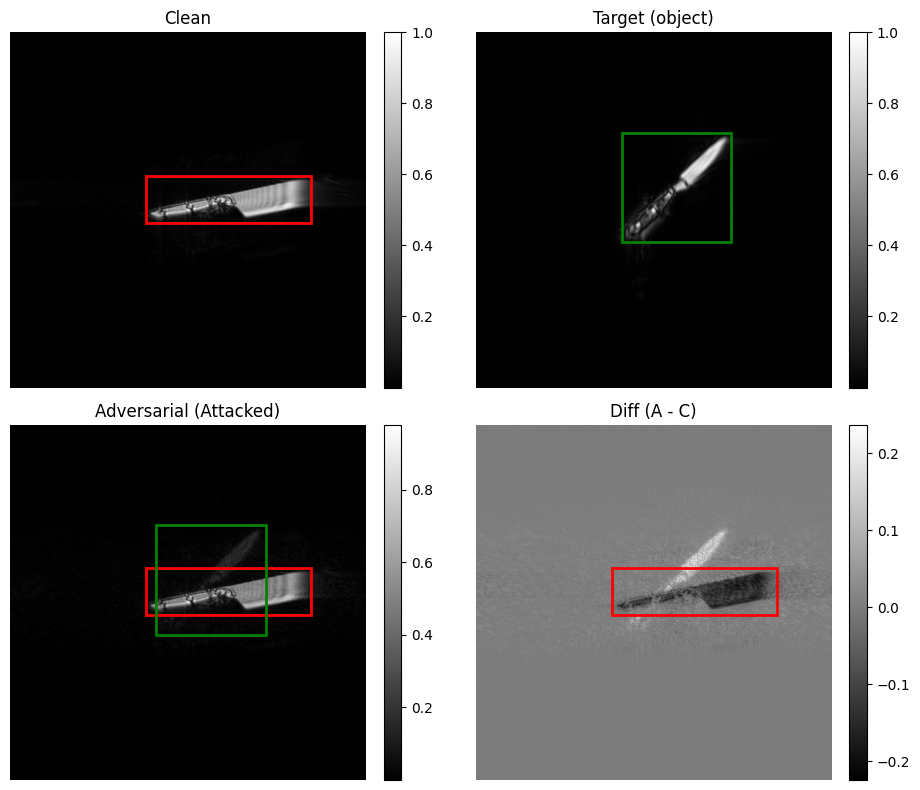

'\n# ============================================================\n# 11) FINAL EVALUATION + VISUALIZATION (WITH MATLAB-LIKE FLIP)\n#   - Applies the SAME left-right flip to ALL displayed images\n#     (clean / target / adv / diff) to match your MATLAB fliplr\n# ============================================================\n\nimport math\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nimport matplotlib.pyplot as plt\nfrom skimage.metrics import structural_similarity as ssim\nfrom skimage.metrics import peak_signal_noise_ratio as psnr\n\nEPS = 1e-12\n\nwith torch.no_grad():\n    # ---- reconstruct attacked measurements\n    A_opt = torch.complex(A_re, A_im)                     # (Np,)\n    delta_opt = D_t * A_opt.unsqueeze(0)                  # (Nsamp, Np)\n    X_opt = X_v_t + delta_opt                             # (Nsamp, Np)\n\n    # ---- reconstruct attacked image via victim pipeline\n    if mode == "rma":\n        adv_mag, _ = victim_forward(X_opt, params_torch, m

In [ ]:
# ============================================================
# 11) FINAL EVALUATION + VISUALIZATION
#     ROI-based for target_mode == "object"
#     full-image for target_mode == "noise"
# ============================================================

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

EPS = 1e-12

# -------------------------
# ROI helpers
# -------------------------
def get_roi_box(img2d, thr_frac=0.25, pad=6):
    """
    img2d: (H,W) numpy array
    returns: (r1, r2, c1, c2), inclusive
    """
    A = np.abs(img2d).astype(np.float64)
    A = A / (A.max() + EPS)

    rows = np.where(np.max(A, axis=1) > thr_frac)[0]
    cols = np.where(np.max(A, axis=0) > thr_frac)[0]

    if rows.size == 0 or cols.size == 0:
        r, c = np.unravel_index(np.argmax(A), A.shape)
        rows = np.array([r], dtype=int)
        cols = np.array([c], dtype=int)

    r1 = max(int(rows[0])  - pad, 0)
    r2 = min(int(rows[-1]) + pad, A.shape[0] - 1)
    c1 = max(int(cols[0])  - pad, 0)
    c2 = min(int(cols[-1]) + pad, A.shape[1] - 1)

    return (r1, r2, c1, c2)


def crop_box(img2d, box):
    r1, r2, c1, c2 = box
    return img2d[r1:r2+1, c1:c2+1]


def compute_metrics_roi(x, y):
    """
    x, y: cropped numpy arrays with same shape
    """
    x = x.astype(np.float64)
    y = y.astype(np.float64)

    mse = np.mean((x - y) ** 2)

    num = np.sum(x * y)
    den = np.sqrt(np.sum(x**2) * np.sum(y**2)) + EPS
    ncc = num / den

    dr = float(y.max() - y.min()) + EPS

    if x.shape == y.shape and min(x.shape) >= 11:
        ssim_val = ssim(x, y, data_range=dr)
    else:
        ssim_val = np.nan

    if x.shape == y.shape:
        psnr_val = psnr(y, x, data_range=dr)
    else:
        psnr_val = 10.0 * np.log10((dr**2) / (mse + EPS))

    return {
        "mse": mse,
        "ncc": ncc,
        "ssim": ssim_val,
        "psnr": psnr_val,
    }


def draw_roi_box(ax, box, color="r", lw=2):
    r1, r2, c1, c2 = box
    rect = Rectangle(
        (c1, r1),
        c2 - c1 + 1,
        r2 - r1 + 1,
        fill=False,
        edgecolor=color,
        linewidth=lw
    )
    ax.add_patch(rect)


with torch.no_grad():
    # ---- reconstruct attacked measurements
    A_opt = torch.complex(A_re, A_im)                     # (Np,)
    delta_opt = D_t * A_opt.unsqueeze(0)                  # (Nsamp, Np)
    X_opt = X_v_t + delta_opt                             # (Nsamp, Np)

    # ---- reconstruct attacked image via victim pipeline
    if mode == "rma":
        adv_mag, _ = victim_forward(X_opt, params_torch, mode="rma")
        adv_img = adv_mag.unsqueeze(0).unsqueeze(0)       # (1,1,H,W)
        adv_img = adv_img / (adv_img.abs().amax() + EPS)
    else:
        _, _, adv_img = victim_forward(
            X_opt,
            params_torch,
            mode="rma+rmist",
            model=model,
            Phi_r_dag=Phi_r_dag,
            do_rms_norm=False
        )                                                 # (1,1,H,W)
        adv_img = adv_img / global_scale

# -------------------------
# Convert to numpy + MATLAB-like fliplr
# -------------------------
adv2d = adv_img.detach().squeeze().cpu().numpy()
tgt2d = target_img.detach().squeeze().cpu().numpy()
cln2d = clean_img.detach().squeeze().cpu().numpy()

adv2d = np.fliplr(adv2d)
tgt2d = np.fliplr(tgt2d)
cln2d = np.fliplr(cln2d)

# -------------------------
# ROI setup
# -------------------------
roi_thr = 0.25
roi_pad = 6

if target_mode.lower() == "object":
    roi_box_target = get_roi_box(tgt2d, thr_frac=roi_thr, pad=roi_pad)
    roi_box_clean  = get_roi_box(cln2d, thr_frac=roi_thr, pad=roi_pad)

    print(f"Target ROI [r1 r2 c1 c2] = {roi_box_target}")
    print(f"Clean  ROI [r1 r2 c1 c2] = {roi_box_clean}")
else:
    roi_box_target = (0, tgt2d.shape[0]-1, 0, tgt2d.shape[1]-1)
    roi_box_clean  = (0, cln2d.shape[0]-1, 0, cln2d.shape[1]-1)

# -------------------------
# ROI crops for evaluation
# -------------------------
adv_t = crop_box(adv2d, roi_box_target)
tgt_t = crop_box(tgt2d, roi_box_target)

adv_c = crop_box(adv2d, roi_box_clean)
cln_c = crop_box(cln2d, roi_box_clean)

AT = compute_metrics_roi(adv_t, tgt_t)
AC = compute_metrics_roi(adv_c, cln_c)

mse_AT  = AT["mse"]
ncc_AT  = AT["ncc"]
ssim_AT = AT["ssim"]
psnr_AT = AT["psnr"]

mse_AC  = AC["mse"]
ncc_AC  = AC["ncc"]
ssim_AC = AC["ssim"]
psnr_AC = AC["psnr"]

# -------------------------
# Pa/Pr stays global
# -------------------------
with torch.no_grad():
    Pa = (torch.linalg.norm(delta_opt) ** 2).item()
    Pr = (torch.linalg.norm(X_v_t) ** 2).item() + EPS
    PaPr = Pa / Pr
    PaPr_dB = 10.0 * math.log10(PaPr + EPS)

# -------------------------
# Print summary
# -------------------------
print("\n--- FINAL METRICS (ROI FOR OBJECT MODE) ---")
print(f"MSE(A,T)      : {mse_AT:.4e}")
print(f"MSE(A,C)      : {mse_AC:.4e}")
print(f"NCC(A,T)      : {ncc_AT:.4f}")
print(f"NCC(A,C)      : {ncc_AC:.4f}")
print(f"PSNR(A,C)     : {psnr_AC:.2f} dB")
print(f"SSIM(A,C)     : {ssim_AC:.4f}")
print(f"PSNR(A,T)     : {psnr_AT:.2f} dB")
print(f"SSIM(A,T)     : {ssim_AT:.4f}")
print(f"Pa/Pr         : {PaPr:.4e} ({PaPr_dB:.2f} dB)")

# -------------------------
# Visualization with ROI boxes
# -------------------------
clean2d  = np.abs(cln2d)
target2d = np.abs(tgt2d)
adv2d_v  = np.abs(adv2d)
diff2d   = adv2d_v - clean2d

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax = axes[0, 0]
im = ax.imshow(clean2d, cmap="gray", origin="lower")
ax.set_title("Clean")
ax.axis("off")
draw_roi_box(ax, roi_box_clean, color="r", lw=2)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0, 1]
im = ax.imshow(target2d, cmap="gray", origin="lower")
ax.set_title(f"Target ({target_mode})")
ax.axis("off")
draw_roi_box(ax, roi_box_target, color="g", lw=2)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 0]
im = ax.imshow(adv2d_v, cmap="gray", origin="lower")
ax.set_title("Adversarial (Attacked)")
ax.axis("off")
draw_roi_box(ax, roi_box_clean,  color="r", lw=2)
draw_roi_box(ax, roi_box_target, color="g", lw=2)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 1]
im = ax.imshow(diff2d, cmap="gray", origin="lower")
ax.set_title("Diff (A - C)")
ax.axis("off")
draw_roi_box(ax, roi_box_clean, color="r", lw=2)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()